In [1]:
#Importations et Configuration
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Configuration
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = r'C:\Users\bapti\OneDrive\Bureau\cours\IA\projet IA\data'

Répartition des classes :
 cls
Bike    2000
Car     2000
Name: count, dtype: int64


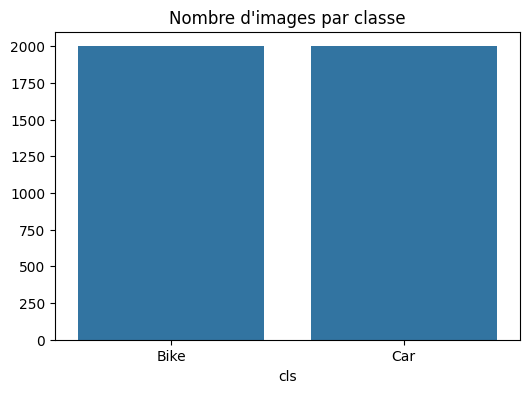

Largeur - Min: 100, Max: 1598, Moy: 279.4
Hauteur - Min: 100, Max: 900, Moy: 194.9


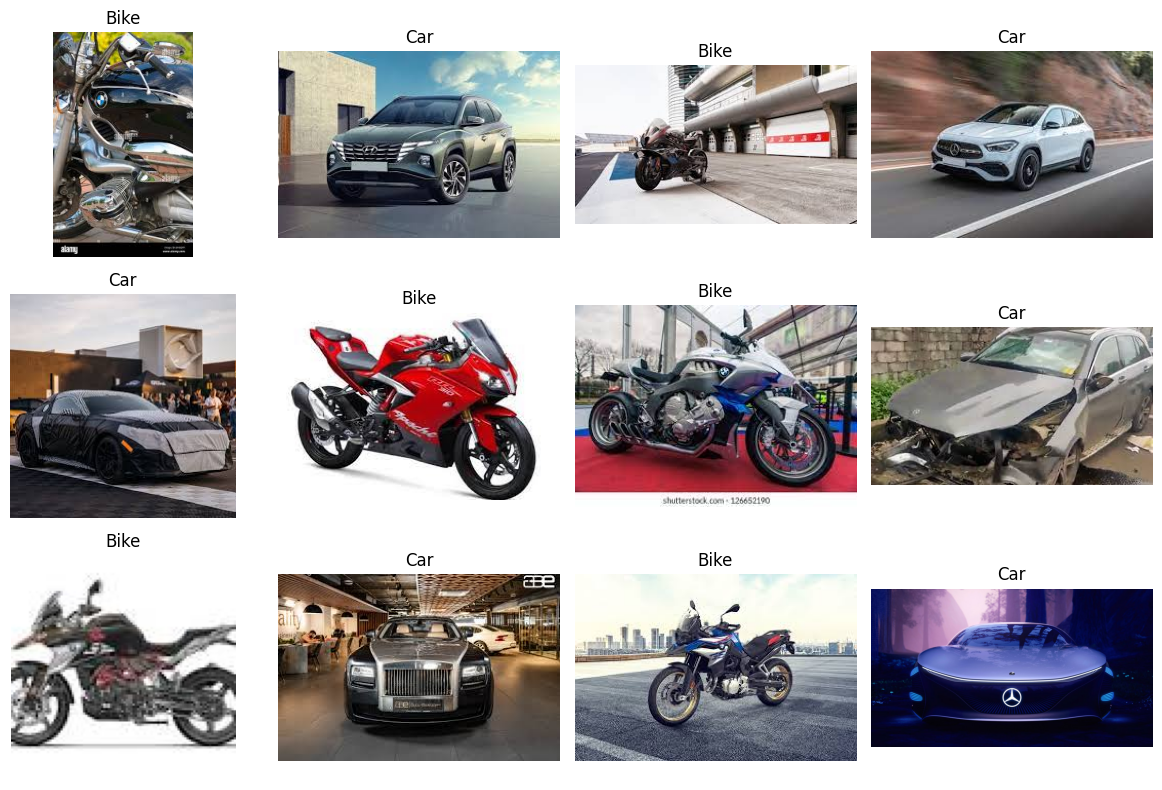

In [2]:
#Partie A - Exploration du dataset

image_files = glob.glob(os.path.join(DATA_DIR, '*', '*.*'))

# 2. Créer le DataFrame df
filepaths = []
labels = []

for file in image_files:
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        filepaths.append(file)
        # Le nom du dossier parent est la classe (ex: 'Car' ou 'Bike')
        labels.append(os.path.basename(os.path.dirname(file)))

df = pd.DataFrame({
    'filepath': filepaths,
    'cls': labels
})

# 3. Compter le nombre d'images par classe
cls_counts = df['cls'].value_counts()
print("Répartition des classes :\n", cls_counts)

# Affichage graphique
plt.figure(figsize=(6,4))
sns.barplot(x=cls_counts.index, y=cls_counts.values)
plt.title("Nombre d'images par classe")
plt.show()

# 4. Calcul des dimensions
sample_df = df.sample(min(100, len(df))) 
widths, heights = [], []

for path in sample_df['filepath']:
    img = cv2.imread(path)
    if img is not None:
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)

print(f"Largeur - Min: {np.min(widths)}, Max: {np.max(widths)}, Moy: {np.mean(widths):.1f}")
print(f"Hauteur - Min: {np.min(heights)}, Max: {np.max(heights)}, Moy: {np.mean(heights):.1f}")

# 5. Afficher quelques images
plt.figure(figsize=(12, 8))
for i in range(12):
    row = df.sample(1).iloc[0]
    img = plt.imread(row['filepath'])
    plt.subplot(3, 4, i+1)
    plt.imshow(img)
    plt.title(row['cls'])
    plt.axis('off')
plt.tight_layout()
plt.show()

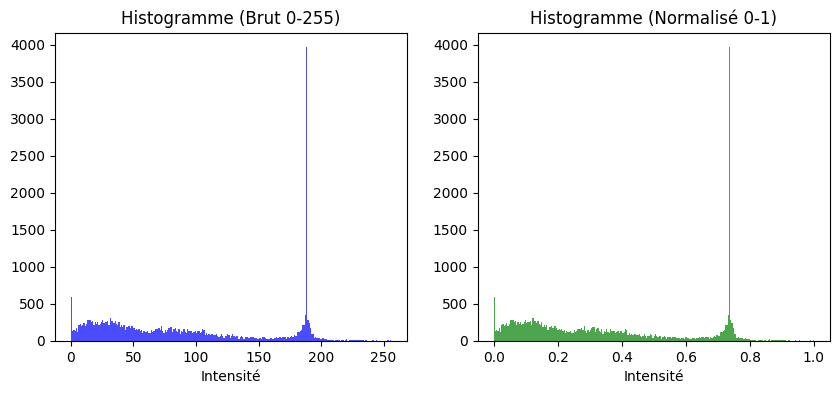

Pixels Brut: Min=0, Max=255
Pixels Norm: Min=0.00, Max=1.00


In [3]:
#Partie B - Pré-traitement et normalisation
# Charger une image test
test_img_path = df.iloc[0]['filepath']
img_raw = cv2.imread(test_img_path)
img_raw = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# 1. Histogramme des intensités brutes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(img_raw.ravel(), bins=256, range=(0, 256), color='blue', alpha=0.7)
plt.title("Histogramme (Brut 0-255)")
plt.xlabel("Intensité")

# 2. Normalisation
img_norm = img_raw / 255.0

plt.subplot(1, 2, 2)
plt.hist(img_norm.ravel(), bins=256, range=(0, 1), color='green', alpha=0.7)
plt.title("Histogramme (Normalisé 0-1)")
plt.xlabel("Intensité")
plt.show()

print(f"Pixels Brut: Min={img_raw.min()}, Max={img_raw.max()}")
print(f"Pixels Norm: Min={img_norm.min():.2f}, Max={img_norm.max():.2f}")

In [4]:
#Partie C - Découpage train/validation/test

# Split 1 : Train (70%) vs Reste (30%)
train_df, dummy_df = train_test_split(
    df, 
    train_size=0.7, 
    stratify=df['cls'], 
    random_state=42
)

# Split 2 : Validation (15%) vs Test (15%)
val_df, test_df = train_test_split(
    dummy_df, 
    train_size=0.5, 
    stratify=dummy_df['cls'], 
    random_state=42
)

print(f"Train size: {len(train_df)} images")
print(f"Val size:   {len(val_df)} images")
print(f"Test size:  {len(test_df)} images")

Train size: 2800 images
Val size:   600 images
Test size:  600 images


In [5]:
#Partie D - Générateurs et Data Augmentation

# 1. Configuration des générateurs
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# 2. Création des flux à partir des DataFrames
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='cls',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='cls',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='cls',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 2800 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.


In [6]:
#Partie E - Modèle MobileNetV2 & Entraînement

# --- Construction du modèle ---

# 1. Charger MobileNetV2 sans le sommet
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=(224, 224, 3)
)

# Geler le backbone pour la Phase 1
base_model.trainable = False

# Ajouter la nouvelle tête de classification
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_vehicle_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Compilation Phase 1
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Début Phase 1 : Entraînement de la tête ---")
history_phase1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)

# --- Phase 2 : Fine-tuning ---

# Débloquer le backbone
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Début Phase 2 : Fine-tuning ---")
history_fine = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=callbacks
)

--- Début Phase 1 : Entraînement de la tête ---
Epoch 1/10
 2/88 ━━━━━━━━━━━━━━━━━━━━ 1:08 800ms/step - accuracy: 0.3906 - loss: 1.1570

C:\Users\bapti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.8234 - loss: 0.3794
Epoch 1: val_accuracy improved from None to 0.98833, saving model to best_vehicle_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9243 - loss: 0.1849 - val_accuracy: 0.9883 - val_loss: 0.0424 - learning_rate: 0.0010
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9718 - loss: 0.0619
Epoch 2: val_accuracy did not improve from 0.98833
88/88 ━━━━━━━━━━━━━━━━━━━━ 64s 729ms/step - accuracy: 0.9732 - loss: 0.0633 - val_accuracy: 0.9883 - val_loss: 0.0406 - learning_rate: 0.0010
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.9721 - loss: 0.0664
Epoch 3: val_accuracy did not improve from 0.98833
88/88 ━━━━━━━━━━━━━━━━━━━━ 62s 708ms/step - accuracy: 0.9786 - loss: 0.0562 - val_accuracy: 0.9867 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9763 - loss: 0.0548
Epoch 4: val_accuracy did not improve from 0.988

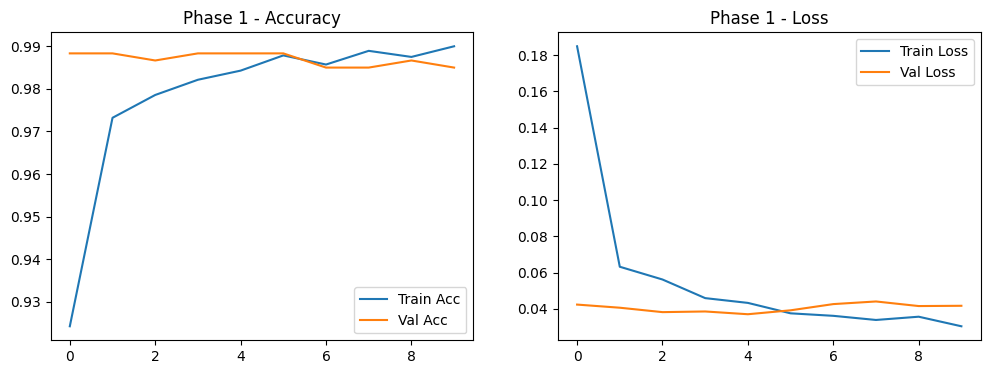

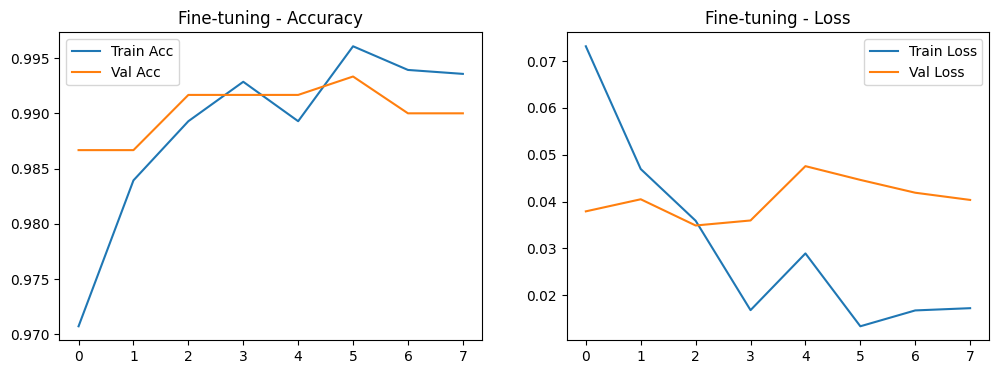


--- Évaluation sur le Test Set ---
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 906ms/step - accuracy: 0.9900 - loss: 0.0439
Test Accuracy: 99.00%
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 654ms/step

Classification Report:

              precision    recall  f1-score   support

        Bike       0.99      0.99      0.99       300
         Car       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



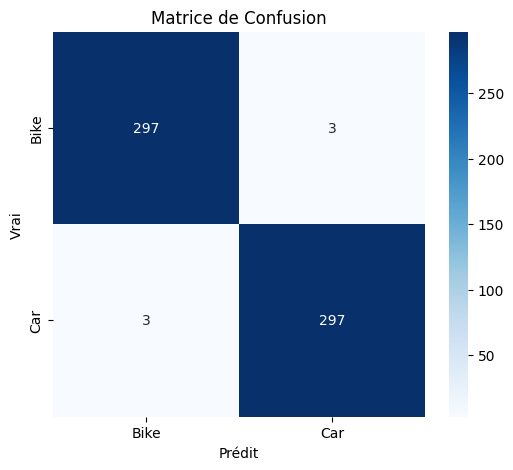

In [7]:
#Partie F - Résultats & Matrice de confusion

# Fonction pour tracer les courbes
def plot_history(hist, title="Phase 1"):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

plot_history(history_phase1, "Phase 1")
plot_history(history_fine, "Fine-tuning")

# --- Évaluation sur le Test Set ---
print("\n--- Évaluation sur le Test Set ---")
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Prédictions
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Rapport de classification
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice de Confusion")
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.show()

Exemple de prédiction correcte :


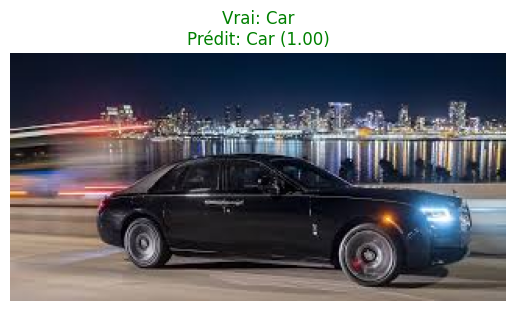

Exemple d'erreur (si existante) :


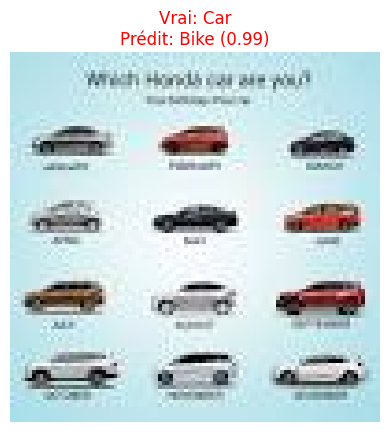

In [8]:
#Partie G - Prédictions individuelles

def predict_by_index(df_test, index, model):
    """
    Prend un index du dataframe de test, charge l'image, et fait une prédiction.
    """
    row = df_test.iloc[index]
    img_path = row['filepath']
    true_label = row['cls']
    
    # Chargement et pré-traitement
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, IMAGE_SIZE)
    img_batch = np.expand_dims(img_resized, axis=0) / 255.0
    
    # Prédiction
    pred_probs = model.predict(img_batch, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_label = class_names[pred_idx]
    confidence = pred_probs[pred_idx]
    
    # Affichage
    plt.imshow(img)
    plt.axis('off')
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"Vrai: {true_label}\nPrédit: {pred_label} ({confidence:.2f})", color=color)
    plt.show()

# Afficher quelques exemples
errors = np.where(y_pred != y_true)[0]
corrects = np.where(y_pred == y_true)[0]

print("Exemple de prédiction correcte :")
if len(corrects) > 0:
    predict_by_index(test_df, corrects[0], model)

print("Exemple d'erreur (si existante) :")
if len(errors) > 0:
    predict_by_index(test_df, errors[0], model)
else:
    print("Bravo ! Aucune erreur sur le jeu de test.")